# 8 source con rumore

**DOT Project – Parte 3, versione multi-sorgente con rumore poissoniano (mezzo semi-infinito)**

Questo notebook spiega, dal punto di vista **teorico** e dal punto di vista dell'**implementazione** (sintassi Python, funzioni NumPy, strutture dati), la prima parte dello script
`DOT_Part3_multisorgente_con_rumore.py`, cioè le **righe 32–126** (STEP 1):

| § | Righe | Contenuto |
|---|---|---|
| 1 | 31–35 | parametri ottici del mezzo: $\mu_a$, $\mu_s'$, $n$, $D$, $v$ |
| 2 | 37–43 | condizioni al contorno: bordo estrapolato ($A$, $z_b$) e sorgente equivalente ($z_0$) |
| 3 | 45–73 | geometria: 8 sorgenti e 9 rivelatori letti dal dizionario `geometria_base` |
| 4 | 75–80 | posizioni 3D reali e **immagine** di sorgenti e rivelatori (metodo delle immagini) |
| 5 | 82–111 | selezione delle **coppie sorgente-rivelatore** (primi vicini / tutte) |
| 6 | 113–125 | **griglia di voxel** del dominio da ricostruire |

(Per far girare il notebook si include anche la riga 31, `mu_a0`, che è la prima riga dello STEP 1.)

**Unità di misura** usate in tutto il codice: lunghezze in **mm**, tempi in **ns**, coefficienti ottici in **mm$^{-1}$**.
In queste unità la velocità della luce nel vuoto è
$$
c = 3\cdot 10^{8}\ \text{m/s} = 3\cdot 10^{2}\ \text{mm/ns}.
$$

Il ruolo di questa sezione nel programma completo è preparare **tutti gli ingredienti geometrici e fisici** che servono dopo per:
- costruire la matrice di sensitività $W$ (STEP 3), le cui righe sono le misure (coppia $p$, gate $g$) e le colonne i voxel;
- simulare le misure $M = W A$ e il rumore poissoniano (STEP 4, 4b);
- invertire il problema (TSVD, ricostruzione vincolata, STEP 5–11).

## 0. Import

```python
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi, exp
```

- `import numpy as np`: importa la libreria NumPy con l'alias `np`; tutte le funzioni si chiamano come `np.array`, `np.linalg.norm`, …
- `import matplotlib.pyplot as plt`: interfaccia di plotting (usata qui solo per i grafici illustrativi).
- `from numpy import pi, exp`: importa **direttamente nel namespace** la costante $\pi$ e la funzione esponenziale $e^{x}$, così le formule della fluenza si possono scrivere come `exp(-...)` invece di `np.exp(-...)`. `exp` è una *ufunc* vettoriale: applicata a un array calcola l'esponenziale elemento per elemento.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi, exp

## 1. Parametri ottici del mezzo (righe 31–35)

### Teoria
La propagazione della luce in un tessuto biologico (mezzo altamente diffondente) è descritta, nel regime di diffusione, dall'**equazione di diffusione** per la fluenza $\Phi(\mathbf r,t)$:
$$
\frac{1}{v}\frac{\partial \Phi(\mathbf r,t)}{\partial t} - D\,\nabla^2\Phi(\mathbf r,t) + \mu_a\,\Phi(\mathbf r,t) = S(\mathbf r,t)
$$
dove:
- $\mu_a$ = coefficiente di **assorbimento** [mm$^{-1}$]: `mu_a0 = 0.01` (valore tipico di tessuto nel vicino infrarosso). L'indice `0` indica il mezzo **di fondo** (imperturbato): l'inclusione sarà poi una perturbazione $\delta\mu_a$.
- $\mu_s' = \mu_s(1-g)$ = coefficiente di **scattering ridotto** [mm$^{-1}$]: `mu_s0 = 1.00`.
- $n$ = indice di rifrazione del mezzo: `n_idx = 1.4`.
- $D$ = **coefficiente di diffusione** [mm]:
$$
D = \frac{1}{3\,\mu_s'}\qquad\Rightarrow\qquad D = \frac{1}{3\cdot 1}\ \text{mm}\approx 0.333\ \text{mm}
$$
  (si usa la definizione indipendente da $\mu_a$, valida per $\mu_a \ll \mu_s'$; qui $\mu_a/\mu_s' = 0.01$).
- $v$ = **velocità della luce nel mezzo** [mm/ns]:
$$
v = \frac{c}{n} = \frac{3\cdot 10^{2}}{1.4}\ \frac{\text{mm}}{\text{ns}} \approx 214.3\ \frac{\text{mm}}{\text{ns}}
$$

La soluzione per sorgente impulsiva puntiforme in **mezzo infinito** (funzione di Green), che il codice userà più avanti in `fluence_inf`, è
$$
\Phi_\infty(\rho,t) = \frac{v}{(4\pi D v t)^{3/2}}\,\exp\!\left(-\frac{\rho^2}{4 D v t} - \mu_a v t\right).
$$

### Implementazione
```python
mu_a0 = 0.01
mu_s0 = 1.00
n_idx = 1.4
D = 1/(3*mu_s0)
v = 3e2/n_idx
```
- Sono semplici **assegnazioni di variabili globali** di tipo `float`.
- `3e2` è la **notazione scientifica** di Python: `3e2` $= 3\times10^2 = 300.0$ (sempre `float`).
- In Python 3 l'operatore `/` è sempre divisione **reale**: `1/(3*mu_s0)` dà `0.333...` (non la divisione intera, che sarebbe `//`).
- Il nome `n_idx` (e non `n`) evita conflitti con variabili generiche `n` usate come argomenti di funzione.

In [2]:
mu_a0 = 0.01      # [mm^-1] assorbimento di fondo
mu_s0 = 1.00      # [mm^-1] scattering ridotto mu_s'
n_idx = 1.4       # indice di rifrazione
D = 1/(3*mu_s0)   # [mm]    coefficiente di diffusione
v = 3e2/n_idx     # [mm/ns] velocita' della luce nel mezzo

print(f"D = {D:.4f} mm,  v = {v:.2f} mm/ns")

D = 0.3333 mm,  v = 214.29 mm/ns


## 2. Condizioni al contorno: bordo estrapolato (righe 37–43)

### Teoria
Il mezzo è **semi-infinito**: occupa $z \ge 0$, con la superficie fisica (dove stanno gli optodi) nel piano $z=0$ e l'aria per $z<0$. Poiché $n_{\text{tessuto}} \neq n_{\text{aria}}$, alla superficie una parte della luce è **riflessa internamente**. La condizione al contorno di tipo Robin (*partial current boundary condition*) è
$$
\Phi(\mathbf r,t)\Big|_{z=0} - 2 A D \,\frac{\partial \Phi}{\partial z}\Big|_{z=0} = 0 ,
\qquad
A = \frac{1 + R_{\text{eff}}}{1 - R_{\text{eff}}}
$$
dove $R_{\text{eff}}$ è il **coefficiente di riflessione effettivo** (frazione di fotoni diffusi riflessa verso l'interno). Per esso si usa il fit polinomiale empirico (Groenhuis *et al.*, Egan & Hilgeman):
$$
R_{\text{eff}}(n) \simeq -\frac{1.4399}{n^2} + \frac{0.7099}{n} + 0.6681 + 0.0636\,n .
$$

**Approssimazione del bordo estrapolato (EBC).** Invece della condizione di Robin si impone $\Phi = 0$ su un piano **virtuale** esterno al mezzo, a distanza
$$
z_b = 2 A D
$$
dalla superficie, cioè nel piano $z = -z_b$.

**Sorgente equivalente.** Il fascio collimato che entra nel tessuto viene sostituito da una sorgente isotropa puntiforme alla profondità di un cammino di trasporto:
$$
z_0 = \frac{1}{\mu_s'} = 1\ \text{mm}.
$$

**Metodo delle immagini.** Per annullare $\Phi$ sul piano $z=-z_b$ si aggiunge alla sorgente reale in $(x_s,y_s,z_0)$ una **sorgente immagine negativa**, speculare rispetto al piano $z=-z_b$:
$$
z_{\text{imm}} = -z_b - (z_0 + z_b) = -z_0 - 2z_b .
$$
La fluenza nel mezzo semi-infinito è allora la differenza di due soluzioni di mezzo infinito:
$$
\Phi_{\text{semi}}(\mathbf r,t) = \Phi_\infty\big(|\mathbf r - \mathbf r_s|,t\big) - \Phi_\infty\big(|\mathbf r - \mathbf r_s'|,t\big),
\qquad
\mathbf r_s = (x_s,y_s,z_0),\quad \mathbf r_s' = (x_s,y_s,-z_0-2z_b).
$$
Per simmetria, in ogni punto del piano $z=-z_b$ i due termini sono uguali e la fluenza è nulla.

### Implementazione
```python
def A_coefficient(n):
    Reff = -1.4399/n**2 + 0.7099/n + 0.6681 + 0.0636*n
    return (1 + Reff)/(1 - Reff)

A_coeff = A_coefficient(n_idx)
z0 = 1/mu_s0
zb = 2*A_coeff*D
```
- `def nome(argomenti):` definisce una **funzione**; il corpo è indentato (4 spazi). `return` restituisce il valore.
- `n**2` è l'**elevamento a potenza** ($n^2$); in Python `^` *non* è la potenza (è lo XOR bit a bit).
- `Reff` è una **variabile locale**: esiste solo dentro la funzione.
- La funzione è scritta in forma generale (argomento `n`) e poi valutata in `n_idx`: così si può riusare con altri indici di rifrazione.
- Il risultato si chiama `A_coeff` (e non `A`) perché `A` sarà il **vettore dei voxel** (STEP 2).

In [3]:
def A_coefficient(n):
    Reff = -1.4399/n**2 + 0.7099/n + 0.6681 + 0.0636*n
    return (1 + Reff)/(1 - Reff)

A_coeff = A_coefficient(n_idx)
z0 = 1/mu_s0          # [mm] profondita' della sorgente equivalente
zb = 2*A_coeff*D      # [mm] distanza del bordo estrapolato

Reff = -1.4399/n_idx**2 + 0.7099/n_idx + 0.6681 + 0.0636*n_idx
print(f"R_eff = {Reff:.4f},  A = {A_coeff:.4f}")
print(f"z0 = {z0:.3f} mm,  zb = {zb:.3f} mm")
print(f"sorgente immagine a z = -z0-2zb = {-z0-2*zb:.3f} mm")

R_eff = 0.5296,  A = 3.2514
z0 = 1.000 mm,  zb = 2.168 mm
sorgente immagine a z = -z0-2zb = -5.335 mm


**Verifica numerica del metodo delle immagini.** Calcoliamo $\Phi_{\text{semi}}$ lungo $z$ sotto una sorgente: deve annullarsi esattamente in $z=-z_b$.
(`fluence_inf` è la stessa funzione definita più avanti nello script, allo STEP 3.)

Phi(z = -zb) = 0.00e+00   (deve essere 0)


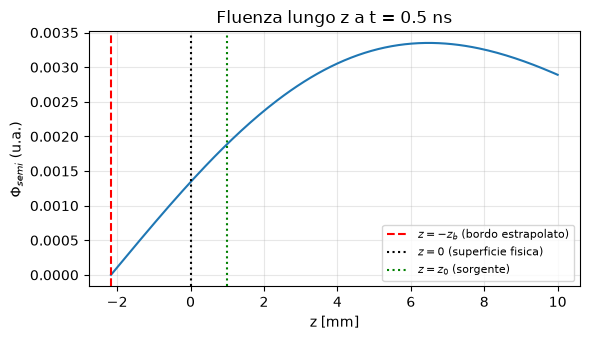

In [4]:
def fluence_inf(mu_a0, mu_s0, n, t, r):
    D = 1/(3*mu_s0); v = 3e2/n
    return (v/(4*pi*D*v*t)**(3/2))*exp(-(r**2/(4*D*v*t)) - mu_a0*v*t)

z = np.linspace(-zb, 10, 200)         # punti sull'asse della sorgente, x = y = 0
t_test = 0.5                          # [ns]
phi = (fluence_inf(mu_a0, mu_s0, n_idx, t_test, np.abs(z - z0))
       - fluence_inf(mu_a0, mu_s0, n_idx, t_test, np.abs(z - (-z0 - 2*zb))))
print(f"Phi(z = -zb) = {phi[0]:.2e}   (deve essere 0)")

plt.figure(figsize=(6, 3.5))
plt.plot(z, phi)
plt.axvline(-zb, color='r', ls='--', label='$z=-z_b$ (bordo estrapolato)')
plt.axvline(0, color='k', ls=':', label='$z=0$ (superficie fisica)')
plt.axvline(z0, color='g', ls=':', label='$z=z_0$ (sorgente)')
plt.xlabel('z [mm]'); plt.ylabel(r'$\Phi_{semi}$ (u.a.)'); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title(f'Fluenza lungo z a t = {t_test} ns'); plt.tight_layout(); plt.show()

## 3. Geometria: sorgenti e rivelatori (righe 45–73)

### Teoria
Il sistema di misura è una **sonda** appoggiata sulla superficie $z=0$ con 8 sorgenti (S) e 9 rivelatori (D) disposti su una griglia di passo 12 mm:

```
  y [mm]
   24 |          S5      D3      S6
   12 |          D2      S1      D4
    0 |  D9      S2      D1      S3      D8
  -12 |          D6      S4      D5
  -24 |          S8      D7      S7
      +---------------------------------------
        -24     -12       0      12      24   x [mm]
```
Sorgenti e rivelatori sono alternati a scacchiera: ogni sorgente ha i suoi **primi vicini** a $\rho = 12$ mm. Nella **tomografia ottica diffusa (DOT)** usare più sorgenti e più rivelatori significa sondare il volume lungo molti cammini diversi: ogni coppia sorgente-rivelatore è sensibile a una regione a forma di "banana" che unisce i due punti, e l'incrocio di tante banane permette di localizzare l'inclusione in 3D.

### Implementazione
La geometria è salvata in un **dizionario** (`dict`) con due chiavi:
- `"unit"`: stringa con l'unità di misura (documentazione);
- `"points"`: **lista** di dizionari, uno per punto, con chiavi `"type"` (`"source"`/`"detector"`), `"x"`, `"y"`.

Questo formato (simile a un file JSON) separa i *dati* della geometria dal codice: per cambiare sonda basta cambiare la lista.

Le coordinate si estraggono con una **list comprehension con filtro**:
```python
src_xy = np.array([[p["x"], p["y"]] for p in geometria_base["points"]
                   if p["type"] == "source"], dtype=float)
```
che si legge: *"per ogni punto `p` della lista, se il suo tipo è `"source"`, prendi la coppia `[x, y]`"*. Il risultato è una lista di liste, convertita da `np.array(..., dtype=float)` in un array 2D di forma `(N_src, 2)`; `dtype=float` forza il tipo reale (le coordinate nel dizionario sono interi e senza `dtype` l'array sarebbe di interi).

- `src_xy.shape` è la tupla `(righe, colonne)`; `src_xy.shape[0]` è il numero di righe = numero di sorgenti.
- `N_src, N_det = a, b` è un'**assegnazione multipla** (tuple unpacking).
- L'**ordine** delle sorgenti/rivelatori nell'array è quello in cui compaiono nella lista: S1 = (0,12), S2 = (−12,0), …; D1 = (0,0), D2 = (−12,12), … Queste etichette (con indice che parte da 1, mentre in Python gli indici partono da 0) sono usate in tutte le stampe e nei grafici.

In [5]:
geometria_base = {
    "unit": "mm",
    "points": [
        {"type": "detector", "x": 0,   "y": 0},
        {"type": "source",   "x": 0,   "y": 12},
        {"type": "source",   "x": -12, "y": 0},
        {"type": "source",   "x": 12,  "y": 0},
        {"type": "source",   "x": 0,   "y": -12},
        {"type": "detector", "x": -12, "y": 12},
        {"type": "detector", "x": 0,   "y": 24},
        {"type": "detector", "x": 12,  "y": 12},
        {"type": "detector", "x": 12,  "y": -12},
        {"type": "detector", "x": -12, "y": -12},
        {"type": "detector", "x": 0,   "y": -24},
        {"type": "detector", "x": 24,  "y": 0},
        {"type": "detector", "x": -24, "y": 0},
        {"type": "source",   "x": -12, "y": 24},
        {"type": "source",   "x": 12,  "y": 24},
        {"type": "source",   "x": 12,  "y": -24},
        {"type": "source",   "x": -12, "y": -24},
    ],
}

src_xy = np.array([[p["x"], p["y"]] for p in geometria_base["points"]
                   if p["type"] == "source"], dtype=float)
det_xy = np.array([[p["x"], p["y"]] for p in geometria_base["points"]
                   if p["type"] == "detector"], dtype=float)
N_src, N_det = src_xy.shape[0], det_xy.shape[0]

print("src_xy.shape =", src_xy.shape, " dtype =", src_xy.dtype)
print("det_xy.shape =", det_xy.shape)
for i, (x, y) in enumerate(src_xy):
    print(f"  S{i+1}: ({x:+.0f}, {y:+.0f}) mm")
for i, (x, y) in enumerate(det_xy):
    print(f"  D{i+1}: ({x:+.0f}, {y:+.0f}) mm")

src_xy.shape = (8, 2)  dtype = float64
det_xy.shape = (9, 2)
  S1: (+0, +12) mm
  S2: (-12, +0) mm
  S3: (+12, +0) mm
  S4: (+0, -12) mm
  S5: (-12, +24) mm
  S6: (+12, +24) mm
  S7: (+12, -24) mm
  S8: (-12, -24) mm
  D1: (+0, +0) mm
  D2: (-12, +12) mm
  D3: (+0, +24) mm
  D4: (+12, +12) mm
  D5: (+12, -12) mm
  D6: (-12, -12) mm
  D7: (+0, -24) mm
  D8: (+24, +0) mm
  D9: (-24, +0) mm


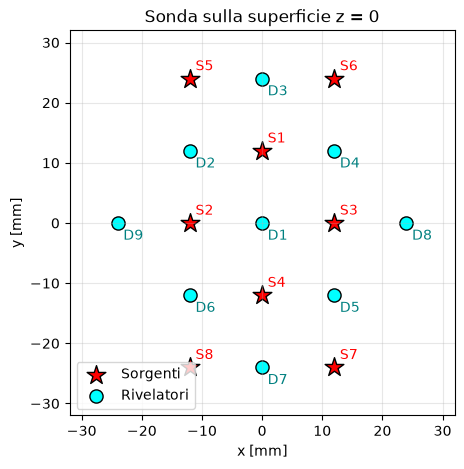

In [6]:
# grafico illustrativo della sonda (non presente nelle righe 32-126)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(*src_xy.T, marker='*', s=200, c='red', edgecolors='k', label='Sorgenti')
ax.scatter(*det_xy.T, marker='o', s=90, c='cyan', edgecolors='k', label='Rivelatori')
for i, (x, y) in enumerate(src_xy):
    ax.annotate(f'S{i+1}', (x, y), xytext=(4, 6), textcoords='offset points', color='red')
for i, (x, y) in enumerate(det_xy):
    ax.annotate(f'D{i+1}', (x, y), xytext=(4, -12), textcoords='offset points', color='teal')
ax.set(xlim=(-32, 32), ylim=(-32, 32), aspect='equal', xlabel='x [mm]', ylabel='y [mm]',
       title='Sonda sulla superficie z = 0')
ax.grid(alpha=.3); ax.legend(loc='lower left'); plt.show()

## 4. Posizioni 3D reali e immagine (righe 75–80)

### Teoria
Per ogni sorgente $s$ con coordinate superficiali $(x_s, y_s)$:
$$
\mathbf r_{s}^{(0)} = (x_s,\ y_s,\ z_0),\qquad
\mathbf r_{s}^{(i)} = (x_s,\ y_s,\ -z_0-2z_b).
$$
Per ogni rivelatore $d$ con coordinate $(x_d, y_d)$:
$$
\mathbf r_{d}^{(0)} = (x_d,\ y_d,\ 0),\qquad
\mathbf r_{d}^{(i)} = (x_d,\ y_d,\ -2z_b).
$$

**Perché anche il rivelatore ha un'immagine?** Nell'approssimazione di **Born al primo ordine**, la variazione di fluenza misurata dovuta a una perturbazione di assorbimento $\delta\mu_a$ in un voxel $\mathbf r_v$ è
$$
\delta\Phi(\mathbf r_d,t) = -\,v\,\delta\mu_a\,V_{\text{vox}}\int_0^t G(\mathbf r_s,\mathbf r_v,t')\,G(\mathbf r_v,\mathbf r_d,t-t')\,dt' ,
$$
cioè la luce va dalla sorgente al voxel ($G(\mathbf r_s,\mathbf r_v)$) e dal voxel al rivelatore ($G(\mathbf r_v,\mathbf r_d)$). Per il **principio di reciprocità** il secondo propagatore è la fluenza generata da una sorgente posta **nel rivelatore**; nel mezzo semi-infinito anche questa va costruita col metodo delle immagini, specchiando il punto $z=0$ rispetto al piano $z=-z_b$:
$$
z^{(i)}_d = -z_b - (0 + z_b) = -2z_b .
$$
Ciascuna delle due funzioni di Green è quindi una differenza reale − immagine:
$$
G_{\text{semi}}(\mathbf r_s,\mathbf r_v) = G_\infty(|\mathbf r_v-\mathbf r_s^{(0)}|) - G_\infty(|\mathbf r_v-\mathbf r_s^{(i)}|),\qquad
G_{\text{semi}}(\mathbf r_v,\mathbf r_d) = G_\infty(|\mathbf r_v-\mathbf r_d^{(0)}|) - G_\infty(|\mathbf r_v-\mathbf r_d^{(i)}|),
$$
e il loro prodotto dà i **4 termini** (reale-reale, reale-immagine, immagine-reale, immagine-immagine) che compaiono nella costruzione di $W$ allo STEP 3:
$$
\delta\Phi_{\text{semi}} = \delta\Phi_\infty(r_{sv}^{(0)}, r_{vd}^{(0)}) - \delta\Phi_\infty(r_{sv}^{(0)}, r_{vd}^{(i)}) - \delta\Phi_\infty(r_{sv}^{(i)}, r_{vd}^{(0)}) + \delta\Phi_\infty(r_{sv}^{(i)}, r_{vd}^{(i)}).
$$
Il rivelatore è posto sulla superficie fisica $z=0$ (e non a $z_0$ come la sorgente) perché misura la luce che **esce** dal tessuto.

### Implementazione
```python
r_s0 = np.column_stack((src_xy, np.full(N_src, z0)))
```
- `np.full(N, valore)` crea un array 1D di lunghezza `N` con tutti gli elementi uguali a `valore` → la colonna delle $z$.
- `np.column_stack((a, b))` affianca **per colonne** gli array della tupla: `src_xy` (forma `(8, 2)`) e la colonna `(8,)` diventano un array `(8, 3)` con righe $(x, y, z)$.
- Convenzione dei nomi: suffisso `0` = punto **reale**, suffisso `i` = punto **immagine**; `s` = sorgente, `d` = rivelatore.

In [7]:
# sorgenti: iniettate a z0 (reale) e -z0-2zb (immagine)
r_s0 = np.column_stack((src_xy, np.full(N_src, z0)))
r_si = np.column_stack((src_xy, np.full(N_src, -z0 - 2*zb)))
# rivelatori: posizione reale a z=0 (superficie fisica) e immagine a -2zb
r_d0 = np.column_stack((det_xy, np.full(N_det, 0.0)))
r_di = np.column_stack((det_xy, np.full(N_det, -2*zb)))

print("np.full(3, z0)  ->", np.full(3, z0))
print("r_s0.shape =", r_s0.shape, " r_d0.shape =", r_d0.shape)
print("S1 reale  :", r_s0[0], "  S1 immagine:", np.round(r_si[0], 3))
print("D1 reale  :", r_d0[0], "  D1 immagine:", np.round(r_di[0], 3))

np.full(3, z0)  -> [1. 1. 1.]
r_s0.shape = (8, 3)  r_d0.shape = (9, 3)
S1 reale  : [ 0. 12.  1.]   S1 immagine: [ 0.    12.    -5.335]
D1 reale  : [0. 0. 0.]   D1 immagine: [ 0.     0.    -4.335]


## 5. Coppie sorgente-rivelatore (righe 82–111)

### Teoria
Una **misura** nel time-domain DOT è la curva temporale (TPSF) raccolta da un rivelatore $d$ quando è accesa una sorgente $s$. La distanza sorgente-rivelatore
$$
\rho_{sd} = \sqrt{(x_s-x_d)^2 + (y_s-y_d)^2}
$$
determina la regione esplorata: la profondità media di penetrazione cresce all'incirca come $\sqrt{\rho}$ e, a $\rho$ fissato, con il **tempo di arrivo** del fotone (i fotoni tardivi hanno viaggiato più in profondità). Per questo il codice più avanti divide la TPSF in **gate temporali**.

Il numero totale di misure è
$$
N_{\text{meas}} = N_{\text{pairs}}\cdot N_{\text{gates}},
$$
e ogni misura corrisponde a una riga della matrice $W$ di indice
$$
\text{riga} = p\cdot N_{\text{gates}} + g ,
$$
con $p$ indice della coppia nella lista `pairs` e $g$ indice del gate.

Due strategie di selezione:
- **`"primi_vicini"`**: per ogni sorgente $s$ si tengono solo i rivelatori $d$ con
$$
\rho_{sd} \le \min_{d'}\rho_{sd'} + \text{tol},
$$
  cioè i più vicini (a meno di una tolleranza `tol_vicini` = 0.5 mm, necessaria perché con numeri reali due distanze "uguali" possono differire per errori di arrotondamento). Le 4 sorgenti interne hanno 4 primi vicini, le 4 esterne ne hanno 2: in totale $4\cdot4 + 4\cdot2 = 24$ coppie, tutte con $\rho = 12$ mm. Segnale molto intenso (poca attenuazione) ma poca informazione in profondità.
- **`"tutte"`** (scelta attuale): tutte le $8\times 9 = 72$ coppie, con $\rho \in \{12;\ 26.8;\ 36;\ 43.3;\ 49.5\}$ mm (vedi l'output qui sotto; il commento nello script, "rho = 12-34 mm", sottostima la distanza massima). Le coppie lontane hanno meno fotoni (più rumore) ma sondano più in profondità e da più direzioni.

Il commento nel codice riassume il risultato dell'analisi con rumore: con i soli primi vicini (e 12 gate) sopra il rumore restano ~25 modi singolari, la risoluzione a 20 mm di profondità è ~20 mm e l'inclusione si localizza ma non si "vede"; con tutte le coppie e 20 gate i modi utili salgono a ~125 e l'inclusione viene ricostruita. In pratica, **più misure indipendenti = più modi singolari sopra il livello del rumore = migliore risoluzione**.

### Implementazione
```python
pairs = []
for s_i in range(N_src):
    dist_sd = np.linalg.norm(det_xy - src_xy[s_i], axis=1)      # (N_det,)
    if modalita_coppie == "primi_vicini":
        d_sel = np.where(dist_sd <= dist_sd.min() + tol_vicini)[0]
    else:
        d_sel = np.arange(N_det)
    pairs += [(s_i, int(d)) for d in d_sel]
```
- `pairs = []` crea una lista vuota che conterrà **tuple** `(indice_sorgente, indice_rivelatore)`.
- `for s_i in range(N_src)`: ciclo sugli indici $0,\dots,N_{src}-1$ → le sorgenti sono trattate **in sequenza** (come in un'acquisizione reale, una sorgente accesa alla volta).
- **Broadcasting**: `det_xy` ha forma `(9, 2)`, `src_xy[s_i]` ha forma `(2,)`; la sottrazione viene "estesa" automaticamente a tutte le righe, producendo i 9 vettori $(x_d - x_s, y_d - y_s)$ senza scrivere un ciclo.
- `np.linalg.norm(..., axis=1)`: norma euclidea **lungo le colonne di ogni riga** → un array `(9,)` di distanze $\rho_{sd}$.
- `dist_sd <= dist_sd.min() + tol_vicini` produce un **array booleano**; `np.where(cond)` restituisce una *tupla* di array di indici (una per dimensione), per questo si prende l'elemento `[0]`.
- `np.arange(N_det)` = `[0, 1, ..., 8]` (tutti i rivelatori).
- `pairs += [...]` concatena alla lista le nuove tuple (equivale a `pairs.extend(...)`); `int(d)` converte l'intero NumPy (`np.int64`) in un intero Python, così le tuple sono "pulite" e usabili come chiavi di dizionario.

Nelle stampe:
- le **f-string** `f"...{espressione:formato}..."` inseriscono valori formattati: `:+.0f` = numero reale con segno esplicito e 0 decimali (`+12`, `-12`), `:.1f` = 1 decimale;
- `", ".join(lista_di_stringhe)` unisce le stringhe separandole con `", "`;
- `f"D{d+1}"`: `+1` perché le etichette partono da 1.

Dopo il ciclo:
```python
N_pairs = len(pairs)
rho_pairs = np.array([np.linalg.norm(src_xy[s] - det_xy[d]) for s, d in pairs])
pair_index = {sd: p for p, sd in enumerate(pairs)}   # (s,d) -> p
```
- `for s, d in pairs` spacchetta ogni tupla nelle due variabili.
- `rho_pairs[p]` è la distanza $\rho$ della coppia $p$.
- `enumerate(pairs)` restituisce le coppie `(p, (s, d))`; la **dict comprehension** costruisce la mappa inversa `(s, d) → p`, che permette di trovare in tempo costante la riga di $W$ di una data coppia (usata negli STEP successivi, es. `pair_index[(0, 3)]`). Una tupla può essere chiave di un dizionario perché è **immutabile** (hashable), a differenza di una lista.

In [8]:
modalita_coppie = "tutte"
tol_vicini = 0.5     # [mm] tolleranza per considerare "uguali" due distanze

pairs = []
print("Selezione coppie sorgente-rivelatore:", modalita_coppie)
for s_i in range(N_src):
    dist_sd = np.linalg.norm(det_xy - src_xy[s_i], axis=1)      # (N_det,)
    if modalita_coppie == "primi_vicini":
        d_sel = np.where(dist_sd <= dist_sd.min() + tol_vicini)[0]
    else:
        d_sel = np.arange(N_det)
    pairs += [(s_i, int(d)) for d in d_sel]
    print(f"  S{s_i+1} ({src_xy[s_i,0]:+.0f},{src_xy[s_i,1]:+.0f}) -> "
          + ", ".join(f"D{d+1}" for d in d_sel)
          + f"   (rho = {dist_sd[d_sel].min():.1f} mm)")
N_pairs = len(pairs)
rho_pairs = np.array([np.linalg.norm(src_xy[s] - det_xy[d]) for s, d in pairs])
pair_index = {sd: p for p, sd in enumerate(pairs)}   # (s,d) -> p

Selezione coppie sorgente-rivelatore: tutte
  S1 (+0,+12) -> D1, D2, D3, D4, D5, D6, D7, D8, D9   (rho = 12.0 mm)
  S2 (-12,+0) -> D1, D2, D3, D4, D5, D6, D7, D8, D9   (rho = 12.0 mm)
  S3 (+12,+0) -> D1, D2, D3, D4, D5, D6, D7, D8, D9   (rho = 12.0 mm)
  S4 (+0,-12) -> D1, D2, D3, D4, D5, D6, D7, D8, D9   (rho = 12.0 mm)
  S5 (-12,+24) -> D1, D2, D3, D4, D5, D6, D7, D8, D9   (rho = 12.0 mm)
  S6 (+12,+24) -> D1, D2, D3, D4, D5, D6, D7, D8, D9   (rho = 12.0 mm)
  S7 (+12,-24) -> D1, D2, D3, D4, D5, D6, D7, D8, D9   (rho = 12.0 mm)
  S8 (-12,-24) -> D1, D2, D3, D4, D5, D6, D7, D8, D9   (rho = 12.0 mm)


In [9]:
# Ispezione delle strutture create
print("N_pairs =", N_pairs)
print("prime 5 coppie:", pairs[:5])
print("pair_index[(0, 3)] =", pair_index[(0, 3)], " -> coppia", pairs[pair_index[(0, 3)]])

rho_u, rho_c = np.unique(np.round(rho_pairs, 2), return_counts=True)
print("\nDistanze s-d distinte [mm] (numero di coppie):")
for r, c in zip(rho_u, rho_c):
    print(f"  rho = {r:5.2f} mm : {c} coppie")

# passo intermedio del ciclo, per la sorgente S1
dist_S1 = np.linalg.norm(det_xy - src_xy[0], axis=1)
print("\nS1: distanze dai 9 rivelatori =", np.round(dist_S1, 2))
print("S1: maschera primi vicini     =", dist_S1 <= dist_S1.min() + tol_vicini)
print("S1: np.where(...)             =", np.where(dist_S1 <= dist_S1.min() + tol_vicini))

N_pairs = 72
prime 5 coppie: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)]
pair_index[(0, 3)] = 3  -> coppia (0, 3)

Distanze s-d distinte [mm] (numero di coppie):
  rho = 12.00 mm : 24 coppie
  rho = 26.83 mm : 28 coppie
  rho = 36.00 mm : 8 coppie
  rho = 43.27 mm : 8 coppie
  rho = 49.48 mm : 4 coppie

S1: distanze dai 9 rivelatori = [12.   12.   12.   12.   26.83 26.83 36.   26.83 26.83]
S1: maschera primi vicini     = [ True  True  True  True False False False False False]
S1: np.where(...)             = (array([0, 1, 2, 3]),)


**Confronto con la modalità `"primi_vicini"`.** La stessa logica, racchiusa in una funzione (senza modificare le variabili globali), mostra le 24 coppie a $\rho=12$ mm.

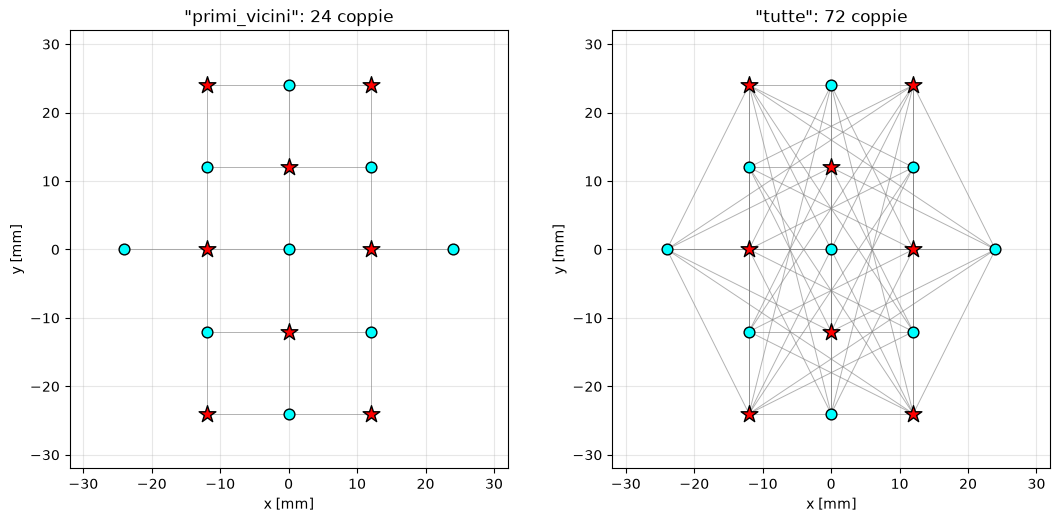

In [10]:
def seleziona_coppie(modalita, tol=0.5):
    out = []
    for s_i in range(N_src):
        dist = np.linalg.norm(det_xy - src_xy[s_i], axis=1)
        d_sel = (np.where(dist <= dist.min() + tol)[0] if modalita == "primi_vicini"
                 else np.arange(N_det))
        out += [(s_i, int(d)) for d in d_sel]
    return out

fig, axs = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, mod in zip(axs, ["primi_vicini", "tutte"]):
    cp = seleziona_coppie(mod)
    for s, d in cp:
        ax.plot(*np.array([src_xy[s], det_xy[d]]).T, color='gray', lw=0.7, alpha=0.6)
    ax.scatter(*src_xy.T, marker='*', s=160, c='red', edgecolors='k', zorder=3)
    ax.scatter(*det_xy.T, marker='o', s=60, c='cyan', edgecolors='k', zorder=3)
    ax.set(aspect='equal', xlim=(-32, 32), ylim=(-32, 32), xlabel='x [mm]', ylabel='y [mm]',
           title=f'"{mod}": {len(cp)} coppie')
    ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Griglia di voxel (righe 113–125)

### Teoria
Il problema inverso è **discretizzato**: il volume sotto la sonda viene suddiviso in voxel cubici di lato $\Delta = 4$ mm e si assume $\delta\mu_a$ costante in ciascun voxel. L'incognita diventa un vettore
$$
A = \big(\delta\mu_{a,1},\ \delta\mu_{a,2},\ \dots,\ \delta\mu_{a,N_{\text{vox}}}\big)^T
$$
e il problema diretto linearizzato è $M = W A$, con $W \in \mathbb R^{N_{\text{meas}}\times N_{\text{vox}}}$.

Il dominio è
$$
x, y \in \left[-\tfrac{L_x}{2},\ \tfrac{L_x}{2}\right] = [-32,\ 32]\ \text{mm},\qquad z\in[0,\ L_z] = [0,\ 32]\ \text{mm},
$$
e i **centri** dei voxel sono
$$
x_i = -\frac{L_x}{2} + \left(i + \tfrac12\right)\Delta,\quad i = 0,\dots,N_x-1,
\qquad
z_k = \left(k + \tfrac12\right)\Delta,\quad k = 0,\dots,N_z-1,
$$
con
$$
N_x = N_y = \frac{L_x}{\Delta} = \frac{64}{4} = 16,\qquad N_z = \frac{L_z}{\Delta} = \frac{32}{4} = 8,\qquad
N_{\text{vox}} = N_x N_y N_z = 2048,
$$
e volume del singolo voxel
$$
V_{\text{vox}} = \Delta^3 = 64\ \text{mm}^3 .
$$
Il voxel entra nella formula di Born come il fattore $\delta\mu_a V_{\text{vox}}$: è l'approssimazione dell'integrale di volume con una somma sui voxel.

Il dominio si estende oltre la sonda (che occupa $|x|,|y|\le 24$ mm) per poter ricostruire anche la luce diffusa lateralmente; in $z$ arriva a 32 mm, oltre la profondità a cui un segnale è ancora rivelabile.

### Implementazione
```python
x_coords = np.arange(-x_ext/2 + step/2, x_ext/2, step)
```
- `np.arange(start, stop, step)` genera valori da `start` **incluso** a `stop` **escluso**, con passo `step`: qui $-30, -26, \dots, 30$ (16 valori). Partire da `-x_ext/2 + step/2` significa che si generano i **centri** (e non i bordi) dei voxel.
- `z_coords` parte da `0 + step/2 = 2` mm: il primo strato di voxel è $[0, 4]$ mm, tutto **dentro** il mezzo.

```python
X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing='ij')
```
- `np.meshgrid` costruisce tre array 3D di forma `(Nx, Ny, Nz)` tali che `X[i,j,k] = x_coords[i]`, `Y[i,j,k] = y_coords[j]`, `Z[i,j,k] = z_coords[k]`.
- `indexing='ij'` (indicizzazione "matriciale") fa corrispondere il primo indice a $x$, il secondo a $y$, il terzo a $z$. Con il default `indexing='xy'` i primi due assi sarebbero scambiati (forma `(Ny, Nx, Nz)`), una fonte classica di errori.

```python
r_V = np.column_stack((X.flatten(), Y.flatten(), Z.flatten()))
```
- `.flatten()` "srotola" l'array 3D in un vettore 1D in ordine **C (row-major)**: l'ultimo indice ($z$) varia più velocemente. Il voxel $(i, j, k)$ va quindi nella posizione
$$
\ell = (i\,N_y + j)\,N_z + k .
$$
- `r_V` ha forma `(N_vox, 3)`: la riga $\ell$ è il centro $(x, y, z)$ del voxel $\ell$, cioè della **colonna $\ell$ di $W$** e dell'elemento $\ell$ di $A$. Lo stesso ordinamento permette di tornare alla forma 3D con `A.reshape(Nx, Ny, Nz)`.

```python
N_vox = r_V.shape[0]
V_vox = step**3
ext_xy = (x_coords[0]-step/2, x_coords[-1]+step/2,
          y_coords[0]-step/2, y_coords[-1]+step/2)
```
- `x_coords[-1]` è l'**ultimo** elemento (indice negativo = contare dalla fine).
- `ext_xy` è una **tupla** `(xmin, xmax, ymin, ymax)` con i bordi *esterni* del dominio ($\pm 32$ mm): è il formato dell'argomento `extent=` di `plt.imshow`, usato in tutte le mappe 2D per far coincidere i pixel dell'immagine con i voxel.

In [11]:
step = 4.0
x_ext = 64.0
z_ext = 32.0
x_coords = np.arange(-x_ext/2 + step/2, x_ext/2, step)
y_coords = np.arange(-x_ext/2 + step/2, x_ext/2, step)
z_coords = np.arange(0 + step/2, z_ext, step)
X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing='ij')
r_V = np.column_stack((X.flatten(), Y.flatten(), Z.flatten()))
N_vox = r_V.shape[0]
V_vox = step**3
ext_xy = (x_coords[0]-step/2, x_coords[-1]+step/2,
          y_coords[0]-step/2, y_coords[-1]+step/2)

print("x_coords =", x_coords)
print("z_coords =", z_coords)
print("X.shape =", X.shape, "  r_V.shape =", r_V.shape)
print(f"N_vox = {N_vox},  V_vox = {V_vox:.0f} mm^3,  ext_xy = {tuple(map(float, ext_xy))}")

x_coords = [-30. -26. -22. -18. -14. -10.  -6.  -2.   2.   6.  10.  14.  18.  22.
  26.  30.]
z_coords = [ 2.  6. 10. 14. 18. 22. 26. 30.]
X.shape = (16, 16, 8)   r_V.shape = (2048, 3)
N_vox = 2048,  V_vox = 64 mm^3,  ext_xy = (-32.0, 32.0, -32.0, 32.0)


In [12]:
# Verifica della regola di indicizzazione  l = (i*Ny + j)*Nz + k
Nx, Ny, Nz = x_coords.size, y_coords.size, z_coords.size
i, j, k = 11, 10, 4
l = (i*Ny + j)*Nz + k
print(f"voxel (i,j,k) = ({i},{j},{k}) -> l = {l}")
print("r_V[l]                     =", r_V[l])
print("(x_i, y_j, z_k)            =", (x_coords[i], y_coords[j], z_coords[k]))
print("np.ravel_multi_index       =", np.ravel_multi_index((i, j, k), (Nx, Ny, Nz)))

# differenza fra indexing='ij' e 'xy': qui Nx = Ny, quindi le forme coincidono,
# ma il significato dei primi due indici e' scambiato
Xxy, _, _ = np.meshgrid(x_coords, y_coords, z_coords)   # default 'xy'
print("\nindexing='ij': X[1,0,0] =", X[1, 0, 0], " (il 1o indice scorre x)")
print("indexing='xy': X[1,0,0] =", Xxy[1, 0, 0], " (il 1o indice scorre y, x resta fermo)")

voxel (i,j,k) = (11,10,4) -> l = 1492
r_V[l]                     = [14. 10. 18.]
(x_i, y_j, z_k)            = (np.float64(14.0), np.float64(10.0), np.float64(18.0))
np.ravel_multi_index       = 1492

indexing='ij': X[1,0,0] = -26.0  (il 1o indice scorre x)
indexing='xy': X[1,0,0] = -30.0  (il 1o indice scorre y, x resta fermo)


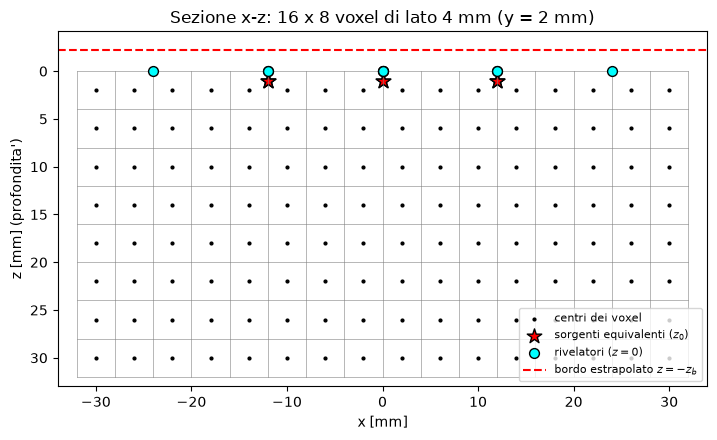

In [13]:
# Sezione verticale x-z del dominio: griglia di voxel, sonda, piani z0 e -zb
fig, ax = plt.subplots(figsize=(10, 4.5))
for xe in np.arange(ext_xy[0], ext_xy[1] + step, step):
    ax.plot([xe, xe], [0, z_ext], color='gray', lw=0.4)
for ze in np.arange(0, z_ext + step, step):
    ax.plot([ext_xy[0], ext_xy[1]], [ze, ze], color='gray', lw=0.4)
XZ = r_V[r_V[:, 1] == y_coords[Ny//2]]
ax.scatter(XZ[:, 0], XZ[:, 2], s=4, c='k', label='centri dei voxel')
ax.scatter(src_xy[:, 0], np.full(N_src, z0), marker='*', s=120, c='red', edgecolors='k',
           label='sorgenti equivalenti ($z_0$)')
ax.scatter(det_xy[:, 0], np.zeros(N_det), marker='o', s=50, c='cyan', edgecolors='k',
           label='rivelatori ($z=0$)', zorder=3)
ax.axhline(-zb, color='r', ls='--', label='bordo estrapolato $z=-z_b$')
ax.set(xlim=(ext_xy[0] - 2, ext_xy[1] + 2), ylim=(z_ext + 1, -zb - 2), aspect='equal',
       xlabel='x [mm]', ylabel='z [mm] (profondita\')',
       title=f'Sezione x-z: {Nx} x {Nz} voxel di lato {step:.0f} mm (y = {y_coords[Ny//2]:.0f} mm)')
ax.legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()

## Riepilogo delle variabili create (righe 32–126)

| Variabile | Tipo / forma | Significato |
|---|---|---|
| `mu_a0`, `mu_s0`, `n_idx` | `float` | $\mu_a$, $\mu_s'$ [mm$^{-1}$], $n$ del mezzo di fondo |
| `D`, `v` | `float` | $D = 1/(3\mu_s')$ [mm], $v = c/n$ [mm/ns] |
| `A_coefficient(n)` | funzione | $A = (1+R_{\text{eff}})/(1-R_{\text{eff}})$ |
| `A_coeff`, `z0`, `zb` | `float` | $A$, $z_0 = 1/\mu_s'$, $z_b = 2AD$ [mm] |
| `geometria_base` | `dict` | descrizione della sonda (unità + lista di punti) |
| `src_xy`, `det_xy` | `(8,2)`, `(9,2)` | coordinate $(x,y)$ di sorgenti e rivelatori |
| `N_src`, `N_det` | `int` | 8, 9 |
| `r_s0`, `r_si` | `(8,3)` | sorgenti reali ($z_0$) e immagine ($-z_0-2z_b$) |
| `r_d0`, `r_di` | `(9,3)` | rivelatori reali ($0$) e immagine ($-2z_b$) |
| `modalita_coppie`, `tol_vicini` | `str`, `float` | criterio di selezione delle coppie |
| `pairs` | lista di tuple `(s,d)` | coppie usate come misure (72 con `"tutte"`) |
| `N_pairs` | `int` | numero di coppie |
| `rho_pairs` | `(N_pairs,)` | distanza $\rho_{sd}$ di ogni coppia |
| `pair_index` | `dict` `(s,d) → p` | indice di coppia (blocco di righe di $W$) |
| `step`, `x_ext`, `z_ext` | `float` | $\Delta$, $L_x = L_y$, $L_z$ [mm] |
| `x_coords`, `y_coords`, `z_coords` | `(16,)`, `(16,)`, `(8,)` | centri dei voxel lungo gli assi |
| `X`, `Y`, `Z` | `(16,16,8)` | griglia 3D (`indexing='ij'`) |
| `r_V` | `(2048,3)` | centro del voxel $\ell$ (colonna $\ell$ di $W$) |
| `N_vox`, `V_vox` | `int`, `float` | 2048 voxel, $V_{\text{vox}} = \Delta^3 = 64$ mm$^3$ |
| `ext_xy` | tupla | `extent` per `imshow` |

Le righe successive dello script (dalla 127) definiscono la **discretizzazione temporale** e i **gate** (`t`, `gates`, `gate_indices`, $N_{\text{meas}} = N_{\text{pairs}} N_{\text{gates}}$), poi l'inclusione (STEP 2), la matrice $W$ (STEP 3) e il rumore poissoniano (STEP 4b).